In [80]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
# Инициализация данных для обработки
import sqlite3

with sqlite3.connect("./data.db3") as con:
    with open('./sql/select_combinations.sql', 'rt') as f:
        sql_query = f.read()
        data = pd.read_sql(sql_query, con)

In [111]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73726 entries, 0 to 73725
Data columns (total 43 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   currency  73726 non-null  object 
 1   t1_dtime  73726 non-null  object 
 2   t1_open   73726 non-null  float64
 3   t1_high   73726 non-null  float64
 4   t1_low    73726 non-null  float64
 5   t1_close  73726 non-null  float64
 6   t1_ma5    73726 non-null  float64
 7   t1_ma10   73726 non-null  float64
 8   t2_dtime  73726 non-null  object 
 9   t2_open   73726 non-null  float64
 10  t2_high   73726 non-null  float64
 11  t2_low    73726 non-null  float64
 12  t2_close  73726 non-null  float64
 13  t2_ma5    73726 non-null  float64
 14  t2_ma10   73726 non-null  float64
 15  t3_dtime  73726 non-null  object 
 16  t3_open   73726 non-null  float64
 17  t3_high   73726 non-null  float64
 18  t3_low    73726 non-null  float64
 19  t3_close  73726 non-null  float64
 20  t3_ma5    73726 non-null  fl

In [112]:
data.head()

,currency,t1_dtime,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_dtime,t2_open,...,t5_close,t5_ma5,t5_ma10,t6_dtime,t6_open,t6_high,t6_low,t6_close,t6_ma5,t6_ma10
0,AUD,2001-02-05 12:00:00,0.5507,0.5531,0.5505,0.5516,0.551600,0.551600,2001-02-06 00:00:00,0.5519,...,0.5465,0.54908,0.549080,2001-02-08 00:00:00,0.5457,0.5464,0.5445,0.5459,0.54794,0.548550
1,AUD,2001-02-06 00:00:00,0.5519,0.5527,0.5480,0.5499,0.550750,0.550750,2001-02-06 12:00:00,0.5498,...,0.5459,0.54794,0.548550,2001-02-08 12:00:00,0.5459,0.5459,0.5415,0.5421,0.54638,0.547629
2,AUD,2001-02-06 12:00:00,0.5498,0.5512,0.5473,0.5480,0.549833,0.549833,2001-02-07 00:00:00,0.5479,...,0.5421,0.54638,0.547629,2001-02-09 00:00:00,0.5420,0.5430,0.5325,0.5368,0.54414,0.546275
3,AUD,2001-02-07 00:00:00,0.5479,0.5507,0.5470,0.5494,0.549725,0.549725,2001-02-07 12:00:00,0.5494,...,0.5368,0.54414,0.546275,2001-02-09 12:00:00,0.5368,0.5370,0.5350,0.5364,0.54154,0.545178
4,AUD,2001-02-07 12:00:00,0.5494,0.5499,0.5444,0.5465,0.549080,0.549080,2001-02-08 00:00:00,0.5457,...,0.5364,0.54154,0.545178,2001-02-10 00:00:00,0.5374,0.5377,0.5342,0.5362,0.53948,0.544280


In [74]:
# Проверка пропусков
data.isnull().sum().sum()

np.int64(0)

In [53]:
COMBINATION_LENGTH = 5
TARGET_CANDLE_PREFIX = f't{(COMBINATION_LENGTH + 1)}_'
LAST_CANDLE_PREFIX = f't{(COMBINATION_LENGTH)}_'

CLASS_LABEL_KEY = 'class'
OPEN_KEY_SUFFIX = 'open'
HIGH_KEY_SUFFIX = 'high'
LOW_KEY_SUFFIX = 'low'
CLOSE_KEY_SUFFIX = 'close'
MA5_KEY_SUFFIX = 'ma5'
MA10_KEY_SUFFIX = 'ma10'
NUMERIC_KEYS_SUFFIXES = (OPEN_KEY_SUFFIX, HIGH_KEY_SUFFIX, LOW_KEY_SUFFIX, CLOSE_KEY_SUFFIX, MA5_KEY_SUFFIX, MA10_KEY_SUFFIX)

DATE_KEY_SUFFIX = 'dtime'
DAY_OF_WEEK_SUFFIX = 'dweek'

IS_WHITE_KEY_SUFFIX = 'is_white'

In [54]:
# Разметка
target_candle_sizes = data[TARGET_CANDLE_PREFIX + HIGH_KEY_SUFFIX] - data[TARGET_CANDLE_PREFIX + LOW_KEY_SUFFIX]
target_candle_body_sizes = np.abs(data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX] - data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX])

buy_class = ((data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] > data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
             (data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] > data[LAST_CANDLE_PREFIX + HIGH_KEY_SUFFIX]) & 
             (target_candle_body_sizes / target_candle_sizes > 0.5))

sell_class = ((data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] < data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
              (data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] < data[LAST_CANDLE_PREFIX + LOW_KEY_SUFFIX]) & 
              (target_candle_body_sizes / target_candle_sizes > 0.5))

data[CLASS_LABEL_KEY] = np.where(buy_class, 1, 
                                 0,)
                                #  np.where(sell_class, 2, 0))
data.value_counts(CLASS_LABEL_KEY)

class
0    62140
1    11586
Name: count, dtype: int64

In [55]:
import mplfinance as mpf

ITEM_INDEXES= range(1, COMBINATION_LENGTH + 1 + 1) # Количество элементов в комбинации + 1 целевой + 1 для невключительной границы

# Транспонирование одного наблюдения в последовательную комбинацию
def transpose_combination(combination_data: pd.Series) -> pd.DataFrame: 
    result = pd.DataFrame(columns=NUMERIC_KEYS_SUFFIXES)
    for i in ITEM_INDEXES:
        result.loc[pd.Timestamp(combination_data.loc[f't{i}_dtime'])] = combination_data.loc[[f't{i}_{key}' for key in NUMERIC_KEYS_SUFFIXES]].values.astype(np.float32)
    return result

def decode_class_label(combination_data: pd.Series) -> tuple[str, str]:
    cls = combination_data.get(CLASS_LABEL_KEY)
    if cls == 1:
        return ('BUY', 'green')
    elif cls == 2:
        return ('SELL', 'red')
    else:
        return ('PASS', 'grey')

# Визуализация комбинации
def print_combination(combination_data: pd.Series) -> None:
    transposed_combination = transpose_combination(combination_data)
    class_text, class_color = decode_class_label(combination_data)
    _, axes = mpf.plot(transposed_combination, type='candle', ylabel='', returnfig=True, title=f'Class: {class_text}')

    ax1 = axes[0]

    # Пометка целевой свечи
    ax1.scatter([COMBINATION_LENGTH], transposed_combination[-1:]['open'], color=class_color, s=100)
    
    # Графики MA до последней целевой свечи
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma5'][:-1], color='#FF9D68', label ='ma5')
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma10'][:-1], color='#FF7A92', label ='ma10')
    
    # График дней недели
    color = 'tab:blue'
    ax2 = ax1.twinx()
    ax2.set_ylabel('Days of week', color=color)
    ax2.plot(transposed_combination.index.day_of_week + 1, marker='o', ls='None', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(0.8, 6.2)
    ax2.grid(False)

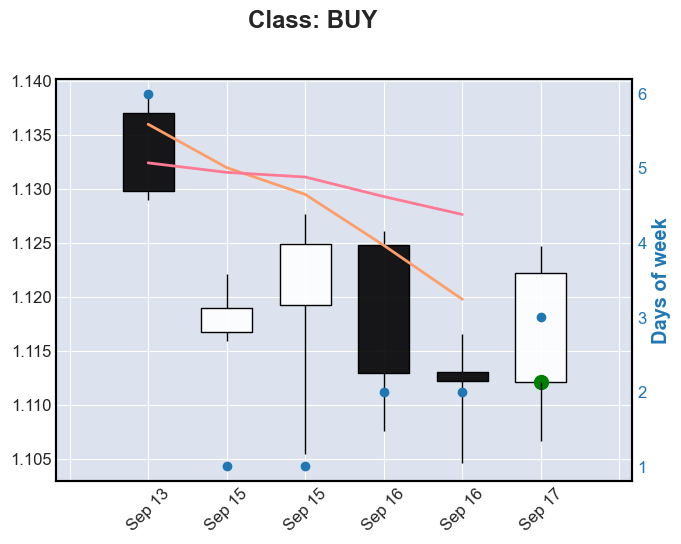

In [9]:
# Печать случайной комбинации
print_combination(data.iloc[np.random.choice(len(data))])

In [68]:
# Предобработка
from datetime import datetime

numeric_columns = [key for key in data.columns if any([key.endswith(suffix) for suffix in NUMERIC_KEYS_SUFFIXES]) and not key.startswith(TARGET_CANDLE_PREFIX)]

# Приведение ценовых показаетелей комбинации в масштаб [0,1]
data_min = data[numeric_columns].min(axis=1)
data_max = data[numeric_columns].max(axis=1)

processed_data = data.copy()
processed_data[numeric_columns] = processed_data[numeric_columns].sub(data_min, axis='rows').divide(data_max - data_min, axis='rows')

# Выделение дня недели
dtime_columns_fields = [(key, key.removesuffix(DATE_KEY_SUFFIX)) for key in data.columns if key.endswith(DATE_KEY_SUFFIX)]
for dtime_key, prefix in dtime_columns_fields:
    processed_data[prefix + DAY_OF_WEEK_SUFFIX] = processed_data[dtime_key].map(lambda t: datetime.fromisoformat(t).weekday())

for i in (range(1, COMBINATION_LENGTH + 1)):
    prefix = f't{i}_'
    
    # Раскраска свечи
    data_open = data[prefix + OPEN_KEY_SUFFIX]
    data_close = data[prefix + CLOSE_KEY_SUFFIX]
    processed_data[prefix + IS_WHITE_KEY_SUFFIX] = (data_close > data_open).astype(np.byte)

In [57]:
processed_data.head()

,currency,t1_dtime,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_dtime,t2_open,...,t5_ma5,t5_ma10,t6_dtime,t6_open,t6_high,t6_low,t6_close,t6_ma5,t6_ma10,class
0,AUD,2001-02-05 12:00:00,0.724138,1.0,0.701149,0.827586,0.827586,0.827586,2001-02-06 00:00:00,0.862069,...,0.537931,0.537931,2001-02-08 00:00:00,0.5457,0.5464,0.5445,0.5459,0.54794,0.548550,0
1,AUD,2001-02-06 00:00:00,0.903614,1.0,0.433735,0.662651,0.765060,0.765060,2001-02-06 12:00:00,0.650602,...,0.426506,0.500000,2001-02-08 12:00:00,0.5459,0.5459,0.5415,0.5421,0.54638,0.547629,0
2,AUD,2001-02-06 12:00:00,0.855670,1.0,0.597938,0.670103,0.859107,0.859107,2001-02-07 00:00:00,0.659794,...,0.503093,0.631811,2001-02-09 00:00:00,0.5420,0.5430,0.5325,0.5368,0.54414,0.546275,0
3,AUD,2001-02-07 00:00:00,0.846154,1.0,0.796703,0.928571,0.946429,0.946429,2001-02-07 12:00:00,0.928571,...,0.639560,0.756868,2001-02-09 12:00:00,0.5368,0.5370,0.5350,0.5364,0.54154,0.545178,0
4,AUD,2001-02-07 12:00:00,0.971264,1.0,0.683908,0.804598,0.952874,0.952874,2001-02-08 00:00:00,0.758621,...,0.519540,0.728608,2001-02-10 00:00:00,0.5374,0.5377,0.5342,0.5362,0.53948,0.544280,0


In [69]:
# Удаление лишних столбцов
dtime_columns = [column[0] for column in dtime_columns_fields]
target_candle_columns = [column for column in processed_data.columns if column.startswith(TARGET_CANDLE_PREFIX)]
droped_columns = ['currency'] + dtime_columns + target_candle_columns

processed_data = processed_data.drop(droped_columns, axis=1)

d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\joblib\externals\loky\backend\context.py:150: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\Apps\Anaconda3\envs\otus-ml\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid

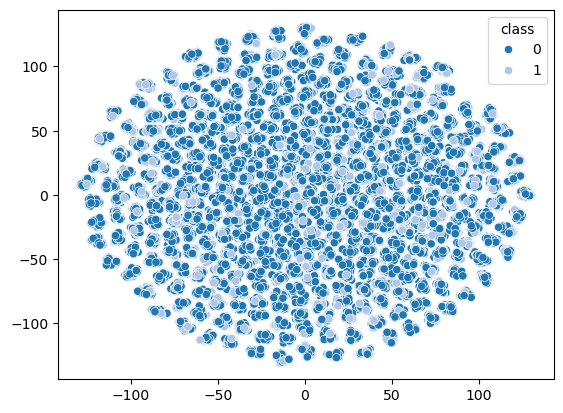

In [12]:
tsne = TSNE(n_components=2, random_state=10)
data_tsne = tsne.fit_transform(processed_data.drop([CLASS_LABEL_KEY], axis=1))

g = sns.scatterplot(x=data_tsne[:,0], y=data_tsne[:,1], palette='tab20', hue=data[CLASS_LABEL_KEY])

C:\Users\mazurenko\AppData\Local\Temp\ipykernel_12976\2827075476.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.scatterplot(x=buy_data_tsne[:,0], y=buy_data_tsne[:,1], palette='tab20')


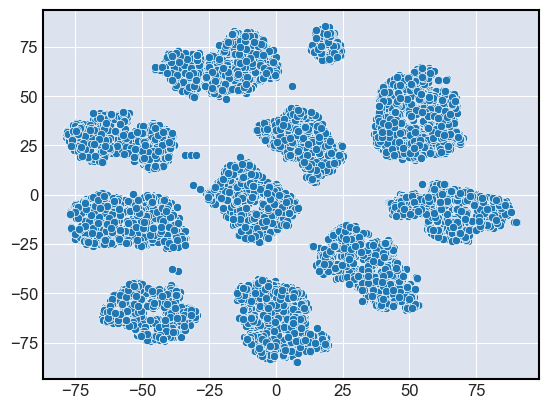

In [ ]:
tsne = TSNE(n_components=2, random_state=10)
buy_data_tsne = tsne.fit_transform(processed_data[processed_data[CLASS_LABEL_KEY] == 1])

g = sns.scatterplot(x=buy_data_tsne[:,0], y=buy_data_tsne[:,1], palette='tab20')

In [59]:
processed_data.head()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t4_close,t4_ma5,t4_ma10,t5_open,t5_high,t5_low,t5_close,t5_ma5,t5_ma10,class
0,0.724138,1.0,0.701149,0.827586,0.827586,0.827586,0.862069,0.954023,0.413793,0.632184,...,0.574713,0.612069,0.612069,0.574713,0.632184,0.000000,0.241379,0.537931,0.537931,0
1,0.903614,1.0,0.433735,0.662651,0.765060,0.765060,0.650602,0.819277,0.349398,0.433735,...,0.253012,0.563855,0.563855,0.156627,0.240964,0.012048,0.180723,0.426506,0.500000,0
2,0.855670,1.0,0.597938,0.670103,0.859107,0.859107,0.659794,0.948454,0.567010,0.814433,...,0.453608,0.663918,0.726804,0.453608,0.453608,0.000000,0.061856,0.503093,0.631811,0
3,0.846154,1.0,0.796703,0.928571,0.946429,0.946429,0.928571,0.956044,0.653846,0.769231,...,0.527473,0.762637,0.831240,0.521978,0.576923,0.000000,0.236264,0.639560,0.756868,0
4,0.971264,1.0,0.683908,0.804598,0.952874,0.952874,0.758621,0.798851,0.689655,0.770115,...,0.247126,0.668966,0.791667,0.247126,0.258621,0.143678,0.224138,0.519540,0.728608,0


In [122]:
buy_data = data[data[CLASS_LABEL_KEY] == 1]
sell_data = data[data[CLASS_LABEL_KEY] == 2]

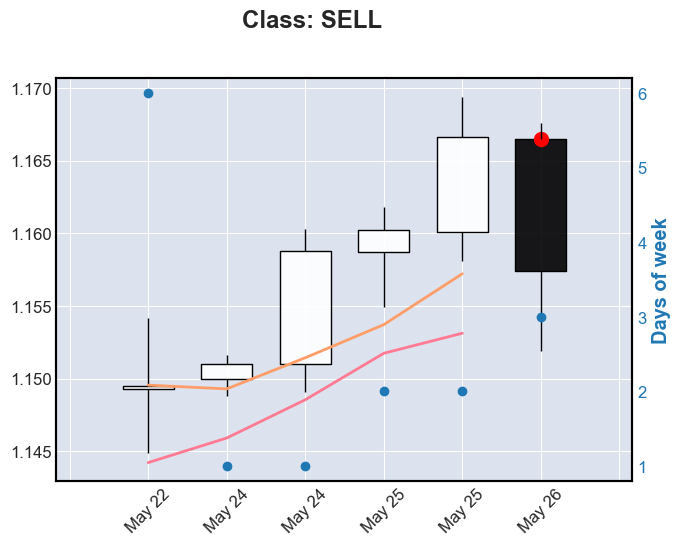

In [123]:
print_combination(sell_data.iloc[np.random.choice(len(sell_data))])

In [82]:
# Моделирование
from sklearn.metrics import precision_score, mean_absolute_error
from sklearn.model_selection import train_test_split

# Разделение на множества данных
X_train, X_test, y_train, y_test = train_test_split(
    processed_data.drop([CLASS_LABEL_KEY], axis=1), processed_data[CLASS_LABEL_KEY], test_size=0.3, random_state=5, shuffle=True, stratify=processed_data[CLASS_LABEL_KEY]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=5, stratify=y_test
)

print(f'Тренировочный набор: {y_train.value_counts()}')
print(f'Валидационный набор: {y_val.value_counts()}')
print(f'Тестовый набор: {y_test.value_counts()}')

Тренировочный набор: class
0    43498
1     8110
Name: count, dtype: int64
Валидационный набор: class
0    9321
1    1738
Name: count, dtype: int64
Тестовый набор: class
0    9321
1    1738
Name: count, dtype: int64


In [79]:
from catboost import CatBoostClassifier

classifier = CatBoostClassifier(n_estimators=1000, 
                                max_depth=10, 
                                learning_rate=0.05, 
                                thread_count=20, 
                                auto_class_weights='Balanced', 
                                leaf_estimation_iterations=3
                                )
                                # auto_class_weights='Balanced', loss_function='CrossEntropy')
classifier.fit(X_train, y_train)
y_train_pred = classifier.predict(X_train)
q_train = precision_score(y_true=y_train, y_pred=y_train_pred
                        )
                        #   , average=None)


print(q_train)

y_val_pred = classifier.predict(X_val)
q_val = precision_score(y_true=y_val, y_pred=y_val_pred
                        )
                        # , average=None)
print(q_val, y_val_pred.sum())

y_test_pred = classifier.predict(X_test)
q_test = precision_score(y_true=y_test, y_pred=y_test_pred
                        )
                        # , average=None)
print(q_test, y_test_pred.sum())

# for d in depth:
#     clf = CatBoostClassifier(n_estimators=n_trees, max_depth=d, logging_level="Silent")
#     clf.fit(X_train, y_train)
#     q_train = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
#     q_test = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
#     quals_cat_train.append(q_train)
#     quals_cat_test.append(q_test)

0:	learn: 0.6897931	total: 36.5ms	remaining: 36.5s
1:	learn: 0.6867290	total: 74.6ms	remaining: 37.2s
2:	learn: 0.6833635	total: 111ms	remaining: 36.9s
3:	learn: 0.6800842	total: 144ms	remaining: 35.8s
4:	learn: 0.6772399	total: 177ms	remaining: 35.3s
5:	learn: 0.6747464	total: 212ms	remaining: 35.1s
6:	learn: 0.6724627	total: 243ms	remaining: 34.4s
7:	learn: 0.6699028	total: 277ms	remaining: 34.3s
8:	learn: 0.6675953	total: 309ms	remaining: 34s
9:	learn: 0.6654116	total: 345ms	remaining: 34.1s
10:	learn: 0.6635069	total: 379ms	remaining: 34.1s
11:	learn: 0.6614957	total: 411ms	remaining: 33.8s
12:	learn: 0.6598487	total: 443ms	remaining: 33.6s
13:	learn: 0.6579608	total: 476ms	remaining: 33.5s
14:	learn: 0.6562641	total: 509ms	remaining: 33.4s
15:	learn: 0.6547477	total: 543ms	remaining: 33.4s
16:	learn: 0.6533120	total: 575ms	remaining: 33.3s
17:	learn: 0.6520397	total: 607ms	remaining: 33.1s
18:	learn: 0.6506912	total: 642ms	remaining: 33.2s
19:	learn: 0.6495660	total: 676ms	remaini

In [ ]:
# Кривая обучения
def train(**kwargs):
    clf = CatBoostClassifier(
        **kwargs,
        learning_rate=0.05, 
        thread_count=3000, 
        auto_class_weights='Balanced', 
        leaf_estimation_iterations=3,
        logging_level="Silent"
        )
    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    q_train = precision_score(y_true=y_train, y_pred=y_train_pred)

    y_val_pred = clf.predict(X_val)
    q_val = precision_score(y_true=y_val, y_pred=y_val_pred)

    print(f'Args: {kwargs}, Val qual: {q_val}, Val pred {y_val_pred.sum()}')

    return q_train, q_val

In [113]:
# Печать кривой обучения
def print_train_curve(title, xlabel, complexity, quals_train, quals_val):
    fig, ax1 = plt.subplots()

    # Общая шкала аргумента
    ax1.set_xlabel(xlabel)
    ax1.set_title(title)

    # Совмещение графиков
    ax2 = ax1.twinx()

    color = 'tab:red'
    ax1.set_ylabel('Train error', color=color)
    ax1.plot(complexity, quals_train, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    color = 'tab:blue'
    ax2.set_ylabel('Val error', color=color)
    ax2.plot(complexity, quals_val, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.show()

Trees: {'n_estimators': 600, 'max_depth': 6}, Val qual: 0.2069492172584956, Val pred 5238
Trees: {'n_estimators': 700, 'max_depth': 6}, Val qual: 0.20773042616451934, Val pred 5045
Trees: {'n_estimators': 800, 'max_depth': 6}, Val qual: 0.20814572247237004, Val pred 4886
Trees: {'n_estimators': 900, 'max_depth': 6}, Val qual: 0.20986869970351546, Val pred 4722
Trees: {'n_estimators': 1000, 'max_depth': 6}, Val qual: 0.2103651869669801, Val pred 4573
Trees: {'n_estimators': 1100, 'max_depth': 6}, Val qual: 0.20986264354875028, Val pred 4441
Trees: {'n_estimators': 1200, 'max_depth': 6}, Val qual: 0.20884749708963912, Val pred 4295


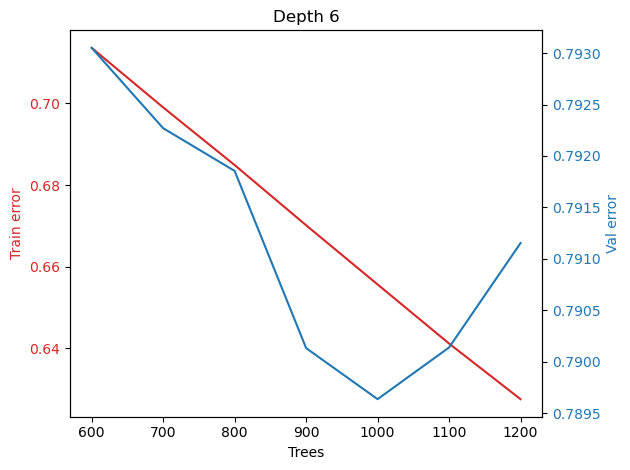

Trees: {'n_estimators': 600, 'max_depth': 7}, Val qual: 0.21308724832214765, Val pred 4768
Trees: {'n_estimators': 700, 'max_depth': 7}, Val qual: 0.21419098143236073, Val pred 4524
Trees: {'n_estimators': 800, 'max_depth': 7}, Val qual: 0.21370499419279906, Val pred 4305
Trees: {'n_estimators': 900, 'max_depth': 7}, Val qual: 0.21489413482599173, Val pred 4109
Trees: {'n_estimators': 1000, 'max_depth': 7}, Val qual: 0.2149886449659349, Val pred 3963
Trees: {'n_estimators': 1100, 'max_depth': 7}, Val qual: 0.21663595683074494, Val pred 3799
Trees: {'n_estimators': 1200, 'max_depth': 7}, Val qual: 0.21865651346206147, Val pred 3677


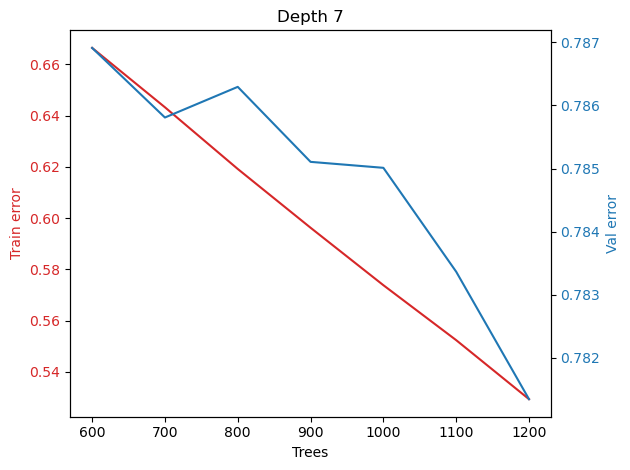

Trees: {'n_estimators': 600, 'max_depth': 8}, Val qual: 0.2117039586919105, Val pred 4067
Trees: {'n_estimators': 700, 'max_depth': 8}, Val qual: 0.2138562091503268, Val pred 3825
Trees: {'n_estimators': 800, 'max_depth': 8}, Val qual: 0.21671826625386997, Val pred 3553
Trees: {'n_estimators': 900, 'max_depth': 8}, Val qual: 0.21381774865991662, Val pred 3358
Trees: {'n_estimators': 1000, 'max_depth': 8}, Val qual: 0.2150031387319523, Val pred 3186
Trees: {'n_estimators': 1100, 'max_depth': 8}, Val qual: 0.21554300896712056, Val pred 3011
Trees: {'n_estimators': 1200, 'max_depth': 8}, Val qual: 0.21261516654854712, Val pred 2822


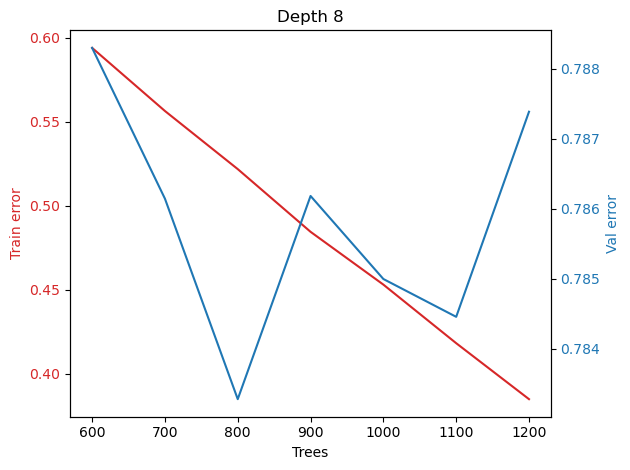

Trees: {'n_estimators': 600, 'max_depth': 9}, Val qual: 0.22006668687481054, Val pred 3299
Trees: {'n_estimators': 700, 'max_depth': 9}, Val qual: 0.21858465608465608, Val pred 3024
Trees: {'n_estimators': 800, 'max_depth': 9}, Val qual: 0.21867054122775154, Val pred 2753
Trees: {'n_estimators': 900, 'max_depth': 9}, Val qual: 0.2178060413354531, Val pred 2516
Trees: {'n_estimators': 1000, 'max_depth': 9}, Val qual: 0.21552471812662619, Val pred 2306
Trees: {'n_estimators': 1100, 'max_depth': 9}, Val qual: 0.20846905537459284, Val pred 2149
Trees: {'n_estimators': 1200, 'max_depth': 9}, Val qual: 0.2115093387178193, Val pred 1981


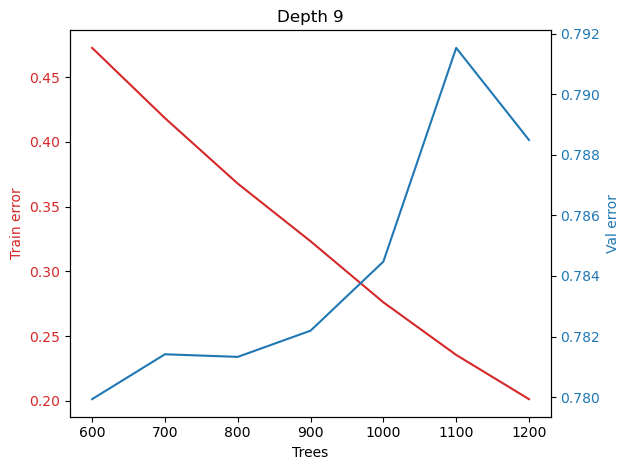

Trees: {'n_estimators': 600, 'max_depth': 10}, Val qual: 0.21915064102564102, Val pred 2496
Trees: {'n_estimators': 700, 'max_depth': 10}, Val qual: 0.21812386156648453, Val pred 2196
Trees: {'n_estimators': 800, 'max_depth': 10}, Val qual: 0.21454545454545454, Val pred 1925
Trees: {'n_estimators': 900, 'max_depth': 10}, Val qual: 0.21577726218097448, Val pred 1724
Trees: {'n_estimators': 1000, 'max_depth': 10}, Val qual: 0.2193211488250653, Val pred 1532
Trees: {'n_estimators': 1100, 'max_depth': 10}, Val qual: 0.22309337134711332, Val pred 1403
Trees: {'n_estimators': 1200, 'max_depth': 10}, Val qual: 0.2266769468003084, Val pred 1297


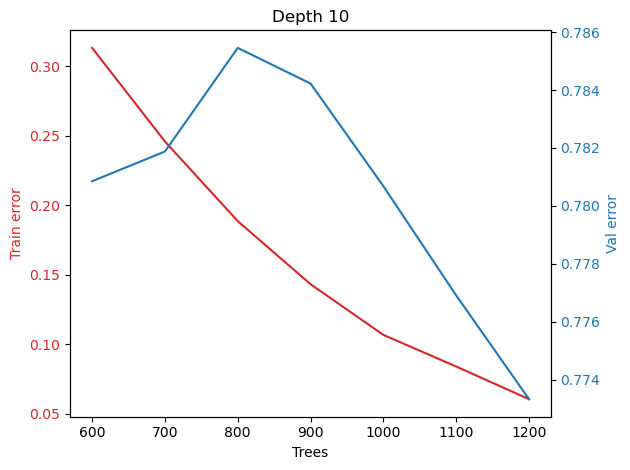

Trees: {'n_estimators': 600, 'max_depth': 11}, Val qual: 0.2286036036036036, Val pred 1776
Trees: {'n_estimators': 700, 'max_depth': 11}, Val qual: 0.22609819121447028, Val pred 1548
Trees: {'n_estimators': 800, 'max_depth': 11}, Val qual: 0.23410620792819745, Val pred 1337
Trees: {'n_estimators': 900, 'max_depth': 11}, Val qual: 0.2365038560411311, Val pred 1167
Trees: {'n_estimators': 1000, 'max_depth': 11}, Val qual: 0.23381642512077294, Val pred 1035
Trees: {'n_estimators': 1100, 'max_depth': 11}, Val qual: 0.2386117136659436, Val pred 922
Trees: {'n_estimators': 1200, 'max_depth': 11}, Val qual: 0.23300970873786409, Val pred 824


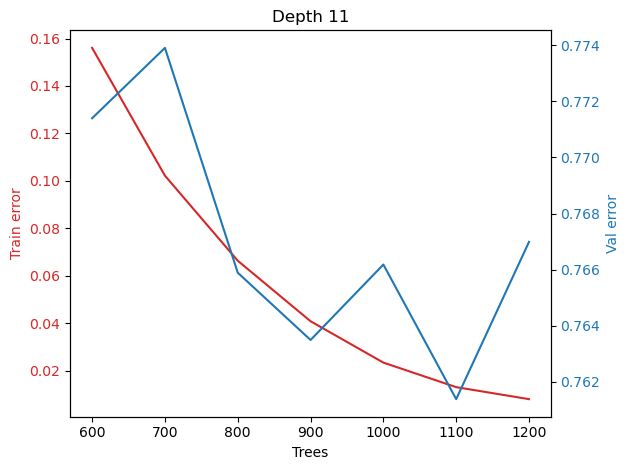

In [ ]:
depth = range(8, 14)
trees = range(800, 1500, 100)
for d in depth:
    quals_train = []
    quals_val = []

    for t in trees:
        q_train, q_val = train(n_estimators=t, max_depth=d)

        quals_train.append(1 - q_train)
        quals_val.append(1 - q_val)

    print_train_curve(f'Depth {d}', 'Trees', trees, quals_train, quals_val)

In [124]:
len(trees[:-1])

6

In [121]:
len(depth)

6

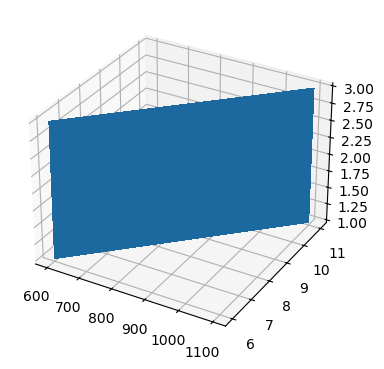

In [ ]:
fig = plt.figure(figsize=plt.figaspect(0.5))

# =============
# First subplot
# =============
# set up the Axes for the first plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# plot a 3D surface like in the example mplot3d/surface3d_demo
X = trees[:-1]
Y = depth
Z = np.array([[1,1,1,1,1,1],[2,2,2,2,2,2],[3,3,3,3,3,3],[3,3,3,3,3,3],[3,3,3,3,3,3],[3,3,3,3,3,3]])
surf = ax1.plot_surface(X, Y, Z, rstride=1, cstride=1,
                       linewidth=0, antialiased=False)

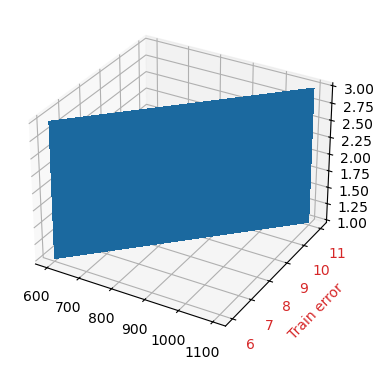

In [131]:
fig = plt.figure(figsize=plt.figaspect(0.5))

# =============
# First subplot
# =============
# set up the Axes for the first plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# plot a 3D surface like in the example mplot3d/surface3d_demo
X = trees[:-1]
Y = depth

color = 'tab:red'
ax1.set_ylabel('Train error', color=color)
ax1.tick_params(axis='y', labelcolor=color)
Z = np.array([[1,1,1,1,1,1],[2,2,2,2,2,2],[3,3,3,3,3,3],[3,3,3,3,3,3],[3,3,3,3,3,3],[3,3,3,3,3,3]])
surf = ax1.plot_surface(X, Y, Z, rstride=1, cstride=1,
                       linewidth=0, antialiased=False)

# ax2 = fig.add_subplot(1, 2, 1, projection='3d')
# color = 'tab:red'
# ax2.set_ylabel('Train error', color=color)
# ax2.tick_params(axis='y', labelcolor=color)
# Z2 = np.array([[1,1,1,1,1,1],[2,2,2,2,2,2],[3,3,3,3,3,3],[3,3,3,3,3,3],[3,3,3,3,3,3],[3,3,3,3,3,3]]) * 2
# surf = ax2.plot_surface(X, Y, Z2, rstride=1, cstride=1,
#                        linewidth=0, antialiased=False)


In [ ]:
fig, ax1 = plt.subplots()

    # Общая шкала аргумента
    ax1.set_xlabel(xlabel)
    ax1.set_title(title)

    # Совмещение графиков
    ax2 = ax1.twinx()

    color = 'tab:red'
    ax1.set_ylabel('Train error', color=color)
    ax1.plot(complexity, quals_train, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    color = 'tab:blue'
    ax2.set_ylabel('Val error', color=color)
    ax2.plot(complexity, quals_val, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.show()

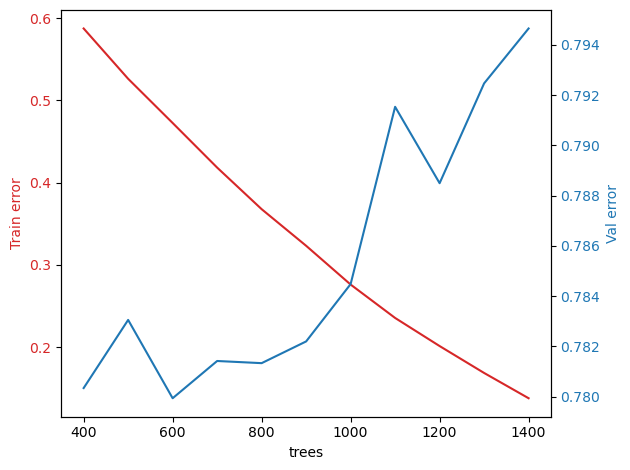

In [19]:
X_train.describe()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t5_high,t5_low,t5_close,t5_ma5,t5_ma10,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek
count,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000,...,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000,51608.000000
mean,0.498016,0.709607,0.286689,0.499947,0.496935,0.494074,0.499290,0.710555,0.289601,0.502754,...,0.715239,0.295037,0.507492,0.504081,0.499798,2.274027,2.275791,2.277534,2.282727,2.281778
std,0.275396,0.242057,0.243339,0.234910,0.269003,0.371902,0.234979,0.217146,0.218685,0.223353,...,0.262383,0.264069,0.297388,0.128583,0.145644,1.596307,1.597405,1.597357,1.599090,1.601734
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.039216,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.078514,0.061607,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.266031,0.518487,0.043243,0.309677,0.270877,0.121053,0.308824,0.546438,0.098901,0.326246,...,0.488783,0.013569,0.231249,0.417021,0.385359,1.000000,1.000000,1.000000,1.000000,1.000000
50%,0.495562,0.735294,0.257282,0.497524,0.492721,0.490373,0.497409,0.731707,0.268105,0.503401,...,0.767442,0.252747,0.513374,0.505610,0.498532,2.000000,2.000000,2.000000,2.000000,2.000000
75%,0.729332,0.948490,0.479863,0.690673,0.724242,0.861865,0.689950,0.899598,0.456396,0.679739,...,1.000000,0.525000,0.783883,0.592070,0.613699,4.000000,4.000000,4.000000,4.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.961478,1.000000,...,1.000000,1.000000,1.000000,0.929996,0.940171,5.000000,5.000000,5.000000,5.000000,5.000000


In [47]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Так как в задаче не предполается тестовый набор праметры масштабирования выучиваются на всём датасете
scaler.fit(X_train)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)

X_val_scaled.describe()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t5_high,t5_low,t5_close,t5_ma5,t5_ma10,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek
count,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,...,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000,11059.000000
mean,0.498589,0.710744,0.288967,0.502336,0.498600,0.497055,0.501228,0.698482,0.300737,0.500442,...,0.715833,0.293897,0.506208,0.498689,0.499294,0.454924,0.451325,0.451451,0.451198,0.453712
std,0.275231,0.240900,0.243421,0.235519,0.269390,0.374394,0.235404,0.225232,0.224523,0.221168,...,0.263971,0.263828,0.298749,0.152437,0.165907,0.321795,0.320696,0.319857,0.318730,0.317901
min,0.000000,0.033058,0.000000,0.001905,0.000000,0.000000,0.000000,0.025478,0.000000,0.000000,...,0.017857,0.000000,0.000000,0.024894,-0.030874,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.267977,0.519544,0.048234,0.312911,0.271017,0.117544,0.313266,0.526902,0.105537,0.326531,...,0.486486,0.010611,0.229711,0.393778,0.367235,0.200000,0.200000,0.200000,0.200000,0.200000
50%,0.491667,0.736504,0.261628,0.500000,0.500000,0.498810,0.500000,0.716636,0.279489,0.500000,...,0.772284,0.253012,0.506250,0.499385,0.499273,0.400000,0.400000,0.400000,0.400000,0.400000
75%,0.731331,0.949517,0.481272,0.689610,0.726445,0.875609,0.687754,0.896856,0.473535,0.672492,...,1.000000,0.523543,0.787234,0.604589,0.628978,0.800000,0.800000,0.800000,0.800000,0.800000
max,1.000000,1.000000,0.982456,1.000000,1.000000,1.000000,1.000000,1.000000,1.021493,1.000000,...,1.000000,0.944873,1.000000,0.999405,0.990851,1.000000,1.000000,1.000000,1.000000,1.000000


In [36]:
y_val_pred.sum()

np.int64(8)

In [27]:
y_val.sum()

np.int64(1738)

In [54]:
103.45 - 90.9

12.549999999999997

In [16]:
(y_val * y_val_pred.squeeze()).count()

np.int64(11059)

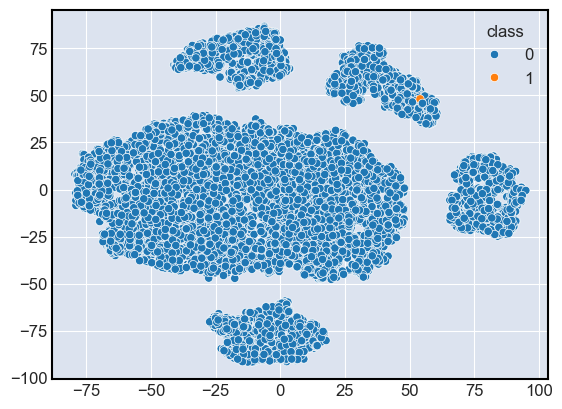

In [48]:
tsne = TSNE(n_components=2, random_state=10)
train_tsne = tsne.fit_transform(X_val_scaled)

g = sns.scatterplot(x=train_tsne[:,0], y=train_tsne[:,1], hue=y_val * y_val_pred.squeeze())